In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import rasterio
import joblib
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from skimage.measure import block_reduce
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata

In [14]:
from utils.site import Site
from utils.tree import Tree
from utils.ethz_map import ETHZMap
from utils.constants import SILVER_FOLDERPATH, ETHZ_COCOA_GH_MAP_UINT8_FILEPATH

In [15]:
ethz_map = ETHZMap.from_tif(ETHZ_COCOA_GH_MAP_UINT8_FILEPATH)

2026-06-03 14:13:13.198 | INFO     | utils.ethz_map:from_tif:5 - Loading /home/aga/Documents/clients/forestero/skymap/skymap/data/silver/cocoa_gh_map_uint8.tif...
2026-06-03 14:13:13.199 | INFO     | utils.ethz_map:from_tif:7 - Boundaries of the map
2026-06-03 14:13:13.199 | INFO     | utils.ethz_map:from_tif:8 - Lon: -3.26° --> 1.19°
2026-06-03 14:13:13.200 | INFO     | utils.ethz_map:from_tif:9 - Lat: 4.54° --> 11.17°
100%|██████████████████████████████████████████████████████████████████████████████████████| 73264/73264 [00:06<00:00, 11123.51it/s]
2026-06-03 14:13:19.846 | INFO     | utils.ethz_map:from_tif:16 - Memory used by array: 3.36 GB


In [6]:
with rasterio.open(ETHZ_COCOA_GH_MAP_UINT8_FILEPATH) as src:
    print("Boundaries of the map")
    print("Lon:", src.bounds.left, "-->", src.bounds.right)
    print("Lat:", src.bounds.bottom, "-->", src.bounds.top)

    # Allocate empty uint8 array 
    data = np.empty(src.shape, dtype=np.uint8)
    
    # Iterate through the file block-by-block to avoid RAM overload
    n_window = len(list(src.block_windows(bidx=1)))
    for idx, (_, window) in enumerate(src.block_windows(bidx=1)):
        print(f"Processing: {idx+1}/{n_window}", end="\r")
        chunk = src.read(indexes=1, window=window, masked=True)
        data[window.toslices()] = chunk

print(f"Memory used by array: {data.nbytes / (1024**3):.2f} GB")

Boundaries of the map
Lon: -3.2607859999999995 --> 1.191657213258483
Lat: 4.5407841018385335 --> 11.1748562
Memory used by array: 3.36 GB


Text(0.5, 1.0, 'ETHZ Cocoa map, scaled down')

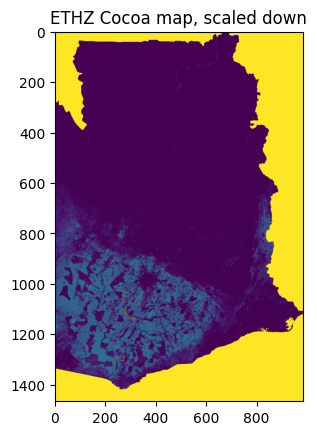

In [7]:
# Plot map
scale_factor = 50
plt.imshow(data[::scale_factor, ::scale_factor])
plt.title("ETHZ Cocoa map, scaled down")

In [11]:
# Look at each site's ETHZ map
sites = joblib.load(SILVER_FOLDERPATH / "sites.pkl")

In [12]:
s = sites[0]

In [14]:
ETHZMap.

ValueError: Number of columns must be a positive integer, not 0

<Figure size 500x600 with 0 Axes>

In [7]:
# Plot value histogram
probs = data[::100, ::100].flatten()
probs = probs[probs != 255]
probs = probs.astype('float16') / 100

Text(0.5, 1.0, 'Probability histogram [prob >=0]')

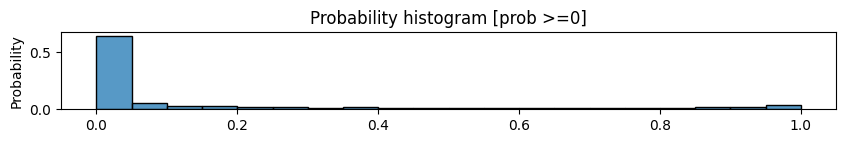

In [8]:
plt.figure(figsize=(10,1))
sns.histplot(probs[probs >= 0], stat='probability', binwidth=0.05)
plt.title("Probability histogram [prob >=0]")

In [9]:
# ETHZ paper reports ~0.9 F1 for thresh >0.65
mask = probs >= 0.9
mask.sum() 

np.int64(35637)